# Gaussian Mixture Model
The GMM is defined as a weighted sum of $K$ Gaussian distribtions:
$$
p(\mathbf{z})=\sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{z}; \mu_k, \Sigma_k)
$$
* $K$: Number of Gaussian components.
* $\pi_k\in [0,1]$: Mixing coefficients, satisfying $\sum_{k=1}^K \pi_k=1$, which ensures the probability density integrates to 1.
* $\mu_k, \Sigma_k$: Mean vector and covariance matrix of the $k$-th Gaussian.
* $\mathcal{N}(\mathbf{z}; \mu_k, \Sigma_k)$: The multivariate Gaussian density of $\mathbf{z}$ dimension $d$: 
$$
\mathcal{N}(\mathbf{z}; \mu_k, \Sigma_k) = \frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}}\exp \left(-\frac{1}{2}(\mathbf{z}-\mu_k)^\intercal\Sigma_k^{-1}(\mathbf{z}-\mu_k)\right)
$$
$$
\nabla \log p(\mathbf{z})=\nabla \log \left(\sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{z}; \mu_k, \Sigma_k)\right)=\frac{\sum_{k=1}^K \pi_k \nabla \mathcal{N}(\mathbf{z}; \mu_k, \Sigma_k)}{p(\mathbf{z})}
$$
$$
\nabla\mathcal{N}(\mathbf{z}; \mu_k, \Sigma_k) = \mathcal{N}(\mathbf{z}; \mu_k, \Sigma_k) \nabla \left(-\frac{1}{2}(\mathbf{z}-\mu_k)^\intercal\Sigma_k^{-1}(\mathbf{z}-\mu_k)\right) = -\mathcal{N}(\mathbf{z}; \mu_k, \Sigma_k) \Sigma_k^{-1}(\mathbf{z}-\mu_k)
$$
* A simplified 2D GMM model with $\Sigma_k = \sigma_k^2 \mathbf{I}$, we have
$$
p(\mathbf{z})=\sum_{k=1}^K \frac{\pi_k}{2\pi \sigma_k^2} \exp\left(-\frac{\|\mathbf{z}-\mu_k\|^2}{2\sigma_k^2}\right)
$$

* A 1D GMM model would have PDF:
$$
p(x)=\sum_{k=1}^K \frac{\pi_k}{\sqrt{2\pi} \sigma_k} \exp\left(-\frac{(x-\mu_k)^2}{2\sigma_k^2}\right)
$$

## The Concrete Example
* p3: $p_{X,Y}(x,y) = \sum_{k=1}^5 \frac{1}{5} \mathcal{N}((x,y); \mathbf{\mu}_k, \sigma_k^2 \mathbf{I})$ where the mean vectors and covariances are:
```python
    means = np.array([[0, 0], [3, 3], [-3, -3], [3, -3], [-3, 3]])
    covariances = np.array([[[0.5, 0], [0, 0.5]]] * n_components)
```
* p1: $p_{X|A}(x | A) = \frac{1}{10} \mathcal{N}(x; \mu_1, \sigma_1^2) + \frac{9}{10} \mathcal{N}(x; \mu_2, \sigma_2^2)$ where the mean vectors and standard deviations are:
```python
    means = np.array([-3, 3])
    stds = np.array([0.5, 0.5])
```
* p2: $p_X(x) = \int_\mathbb{R} p_{X,Y}(x,y)dy$ is the marginal distribution of $X$

**Assumption** We asume that once you know $X$, $A$ gives no further information about $Y$. $A$ influences $X$, $X$ influences $Y$. $$A \perp Y\mid X$$ In other words, $A$ and $Y\mid X$ are conditionally independent. Note that $X\perp Y$ does not hold in the mixture model (nor should it).

* Given the conditional independence assumption, $p(x,y \mid A)$ is well defined and can be obtained via the following identity:
$$
p(x,y\mid A) = p(x\mid A)p(y\mid x, A) =  p(x\mid A)p(y\mid x) = \frac{p(x\mid A)p(x,y)}{p(x)}
$$

### Defining the Diffusion Process
We use the VP-SDE
$$
dZ_t = -\frac{\beta_t}{2}Z_t + \sqrt{\beta_t} dW_t, \quad t\in[0,1]
$$ 
with 
$$
\alpha_t = \exp\left(-\frac{1}{2}\int_0^t \beta_s ds \right)\Longleftrightarrow \beta_t = -\frac{d}{dt}\log (\alpha_t^2)
$$

For the concrete choice $\alpha_t = 1-t$, we have $\beta_t = \frac{2}{1-t}$.

### Closed Form Solution of the Forward Flow
If $Z_0 \sim \mathcal{N}(\mu, \sigma^2I)$, the linear SDE yields the explicit affine propagation:
$$
Z_t = \alpha_t Z_0 + \sqrt{1-\alpha_t^2}\epsilon \sim \mathcal{N}(\mu_t, V_t),\quad \epsilon\sim\mathcal{N}(0,I)
$$
where $\mu_t=\alpha_t\mu$ and $V_t = \alpha_t^2\sigma^2 + (1-\alpha_t^2)$. Hence, the score at time $t$ has a closed form:
$$
\nabla \log p_t(z) = -\frac{z-\mu_t}{V_t}
$$

The reverse SDE is given by
$$
dZ_t = \left(-\frac{\beta_t}{2}Z_t - \beta_t \nabla \log p_t(Z_t) \right)dt + \sqrt{\beta_t}d\bar{W}_t, \quad Z_1 \sim \mathcal{N}(0,I)
$$
We can think of the reverse SDE as a forward SDE for $\tilde{Z}_t = Z_{1-t}$:
$$
d\tilde{Z}_t = -\left(-\frac{\beta_{1-t}}{2}\tilde{Z}_t - \beta_{1-t} \nabla \log p_{1-t}(\tilde{Z}_t) \right)dt + \sqrt{\beta_{1-t}}dW_t, \quad \tilde{Z}_0 \sim \mathcal{N}(0,I)
$$
Plugging the analytic score function gives a closed form for the reverse drift. The GMM examples does not require learning the score function.

To match the notations for Theorem 1, we can write:
$$
d\tilde{Z}_t = \left(\underbrace{\frac{\beta_{1-t}}{2}\tilde{Z}_t + \frac{1}{2}\beta_{1-t} \nabla \log p_{1-t}(\tilde{Z}_t)}_{v_t(Z_t)} + \frac{1}{2}\beta_{1-t} \nabla \log p_{1-t}(\tilde{Z}_t) \right)dt + \sqrt{\beta_{1-t}}dW_t, \quad \tilde{Z}_0 \sim \mathcal{N}(0,I)
$$
where $\sigma_t = \sqrt{\beta_t}$.

device → cuda


/tmp/ipykernel_2115255/2368502091.py:46: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647327489/work/torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor(samples, dtype=torch.float32)


(5000, 2)


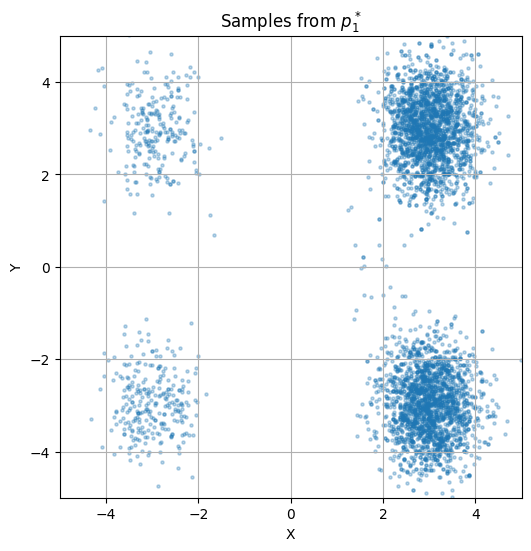

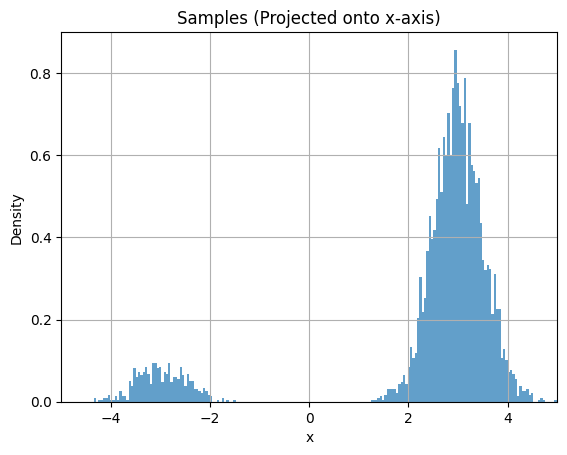

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

### Run this ONCE per experiment
new_experiment = False  # Set to False to reuse an old experiment ID
if new_experiment:  # Run the experiment with the current date and time as the experiment ID
    experiment_id = f"experiment_gmm_{datetime.now().strftime('%Y%m%d')}" #_%H%M%S
    os.makedirs(experiment_id, exist_ok=True)
else:
    experiment_id = "experiment_gmm_20250901"  # Use a fixed ID for reproducibility

bs = 5000


import numpy as np
import torch
from scipy.stats import multivariate_normal, norm

def ground_truth_gmm_2d(bs):
    n_components = 5
    weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
    means = np.array([[0, 0], [3, 3], [-3, -3], [3, -3], [-3, 3]])
    covariances = np.array([[[0.5, 0], [0, 0.5]]] * n_components)
    
    samples = []
    while len(samples) < bs:
        component = np.random.choice(n_components, p=weights)
        sample = np.random.multivariate_normal(means[component], covariances[component])
        samples.append(sample)
    
    return torch.tensor(samples, dtype=torch.float32)


def p_x(x):
    """
    Marginal distribution p(x) from the 2D GMM, 
    i.e. integrate out y: p(x) = ∫ p(x,y) dy
    """
    n_components = 5
    weights = np.ones(n_components) / n_components
    means = np.array([[0, 0], [3, 3], [-3, -3], [3, -3], [-3, 3]])
    covariances = np.array([[[0.5, 0], [0, 0.5]]] * n_components)
    
    px = np.zeros(len(x))
    for w, m, c in zip(weights, means, covariances):
        # marginalize over y: the marginal of a Gaussian is still Gaussian
        mean_x = m[0]
        var_x = c[0,0]
        px += w * norm.pdf(x, loc=mean_x, scale=np.sqrt(var_x))
    return px


def conditional_gmm(bs):
    # draw from joint p(x,y)
    xy = ground_truth_gmm_2d(5*bs).numpy()
    x = xy[:, 0]
    y = xy[:, 1]
    
    
    weights_A = np.array([0.1, 0.9])
    means_A = np.array([-3, 3])
    std_A = np.array([0.5, 0.5])
    
    px_given_A = np.zeros_like(x)
    for w, m, s in zip(weights_A, means_A, std_A):
        px_given_A += w * norm.pdf(x, loc=m, scale=s)
    
    px = p_x(x)
    
    # importance weights
    imp_w = px_given_A / (px + 1e-8)
    imp_w = imp_w / np.sum(imp_w)  # normalize
    
    # resample according to weights
    idx = np.random.choice(len(x), size=5*bs, p=imp_w)
    samples = xy[idx]
    
    return torch.tensor(samples[:bs], dtype=torch.float32)

def conditional_gmm_p1p2(bs):
    # draw from joint p(x,y)
    xy = ground_truth_gmm_2d(5*bs).numpy()
    x = xy[:, 0]
    y = xy[:, 1]
    
    
    weights_A = np.array([0.1, 0.9])
    means_A = np.array([-3, 3])
    std_A = np.array([0.5, 0.5])
    
    px_given_A = np.zeros_like(x)
    for w, m, s in zip(weights_A, means_A, std_A):
        px_given_A += w * norm.pdf(x, loc=m, scale=s)
    
    # importance weights
    imp_w = px_given_A
    imp_w = imp_w / np.sum(imp_w)  # normalize
    
    # resample according to weights
    idx = np.random.choice(len(x), size=5*bs, p=imp_w)
    samples = xy[idx]
    
    return torch.tensor(samples[:bs], dtype=torch.float32)

# samples = ground_truth_gmm_2d(bs).cpu().numpy()
samples = conditional_gmm(bs).cpu().numpy()
print(samples.shape)
plot_diagnostics(samples, torch.zeros(bs), [torch.zeros(bs)], save_name=f"{experiment_id}/ground_truth", full=False)

plt.hist(samples[:,0], bins=200, density=True, alpha=0.7)
plt.title("Samples (Projected onto x-axis)")
plt.grid(True)
plt.xlabel("x"); plt.xlim(-5,5)
plt.ylabel("Density")
plt.show()

In [6]:
import torch
import math

_eps = 1e-12
_TWOPI = 2.0 * math.pi

# -------------------------
# Time schedules (batch-aware)
# -------------------------
def alpha_fn(t):
    # t: [B,1]
    return 1.0 - t          # [B,1]

def beta_fn(t):
    # t: [B,1]
    return 2.0 / (1.0 - t + 1e-2)  # [B,1]

def sigma_fn(t):
    return torch.sqrt(beta_fn(t))    # [B,1]

# -------------------------
# Stable 1D log-normal
# -------------------------
def _log_normal_1d(x, mu, var):
    # x: [B,1] or [B], mu: [B,K], var: [B,K]
    x = x.reshape(-1, 1)           # [B,1]
    log_pref = -0.5 * torch.log(_TWOPI * var)    # [B,K]
    exp_term = -0.5 * ((x - mu)**2) / var        # [B,K]
    return log_pref + exp_term                    # [B,K]

# -------------------------
# 1D time-dependent score for p(x|A)
# -------------------------
def s1_fn(x, t):
    """
    x: [B,1] or [B], t: [B,1]
    returns: score of same shape as x
    """
    device = x.device
    dtype = x.dtype
    B = x.shape[0]

    # GMM parameters for p(x|A)
    pis = torch.tensor([0.1, 0.9], device=device, dtype=dtype)    # [K]
    mus0 = torch.tensor([-3.0, 3.0], device=device, dtype=dtype) # [K]
    sig2_0 = torch.tensor([0.5**2, 0.5**2], device=device, dtype=dtype) # [K]

    K = pis.shape[0]

    # schedule
    alpha = alpha_fn(t)                  # [B,1]
    s2 = 1.0 - alpha**2                  # [B,1]

    # batch-aware component params: mu_t [B,K], tau2 [B,K]
    mu_t = alpha * mus0.reshape(1,K)     # [B,K]
    tau2 = alpha**2 * sig2_0.reshape(1,K) + s2  # [B,K]

    # log components [B,K]
    x_in = x.reshape(B,1)                # [B,1]
    log_comp = torch.log(pis.reshape(1,K)) + _log_normal_1d(x_in, mu_t, tau2)  # [B,K]

    # responsibilities
    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    r = torch.exp(log_comp - logp)                           # [B,K]

    # component scores
    comp_scores = (mu_t - x_in) / (tau2 + _eps)  # [B,K]
    score = (r * comp_scores).sum(dim=1, keepdim=True)  # [B,1]

    if x.ndim == 2 and x.shape[1] == 1:
        return score
    else:
        return score.reshape(-1)  # [B]

# -------------------------
# 1D time-dependent score for p_X (1D marginal)
# -------------------------
def s2_fn(x, t):
    """
    x: [B,1] or [B], t: [B,1]
    returns: score [B,1]
    """
    device = x.device
    dtype = x.dtype
    B = x.shape[0]

    pis = torch.tensor([0.4,0.2,0.4], device=device, dtype=dtype)  # [K]
    mus0 = torch.tensor([-3.0,0.0,3.0], device=device, dtype=dtype)
    sig2_0 = torch.tensor([0.5**2]*3, device=device, dtype=dtype)

    K = pis.shape[0]

    alpha = alpha_fn(t)                 # [B,1]
    s2 = 1.0 - alpha**2                 # [B,1]

    mu_t = alpha * mus0.reshape(1,K)          # [B,K]
    tau2 = alpha**2 * sig2_0.reshape(1,K) + s2  # [B,K]

    x_in = x.reshape(B,1)                   # [B,1]
    log_comp = torch.log(pis.reshape(1,K)) + _log_normal_1d(x_in, mu_t, tau2)  # [B,K]

    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    r = torch.exp(log_comp - logp)                           # [B,K]

    comp_scores = (mu_t - x_in) / (tau2 + _eps)  # [B,K]
    score = (r * comp_scores).sum(dim=1, keepdim=True)  # [B,1]

    if x.ndim == 2 and x.shape[1] == 1:
        return score
    else:
        return score.reshape(-1)
    
    
# -------------------------
# Stable isotropic multivariate log-normal
# -------------------------
def _log_normal_isotropic(x, mus, tau2):
    # x: [B,D], mus: [B,K,D], tau2: [B,K]
    diff2 = ((x.unsqueeze(1) - mus)**2).sum(-1)   # [B,K]
    D = x.shape[1]
    log_pref = -0.5 * D * torch.log(_TWOPI * tau2)   # [B,K]
    exp_term = -0.5 * diff2 / tau2                    # [B,K]
    return log_pref + exp_term                        # [B,K]

# -------------------------
# 2D time-dependent score for p_X (2D GMM)
# -------------------------
def s3_fn(x, t):
    """
    x: [B,2], t: [B,1]
    returns: score [B,2]
    """
    device = x.device
    dtype = x.dtype
    B = x.shape[0]
    K = 5

    pis = torch.ones(K, device=device, dtype=dtype) / K     # [K]
    mus0 = torch.tensor([[0.,0.],[3.,3.],[-3.,-3.],[3.,-3.],[-3.,3.]], device=device, dtype=dtype)  # [K,2]
    sig2_0 = torch.tensor([0.5]*K, device=device, dtype=dtype)  # [K]

    # schedule
    alpha = alpha_fn(t)                 # [B,1]
    s2 = 1.0 - alpha**2                 # [B,1]

    # batch-aware component params: mu_t [B,K,2], tau2 [B,K]
    mu_t = alpha.unsqueeze(1) * mus0.unsqueeze(0)   # [B,K,2]
    tau2 = alpha**2 * sig2_0.reshape(1,K) + s2      # [B,K]

    # log component densities [B,K]
    x_exp = x.unsqueeze(1)             # [B,1,2]
    log_comp = torch.log(pis.reshape(1,K)) + _log_normal_isotropic(x, mu_t, tau2)  # [B,K]

    # responsibilities
    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    r = torch.exp(log_comp - logp)                           # [B,K]

    # component scores [B,K,2]
    comp_scores = (mu_t - x_exp) / (tau2.unsqueeze(-1) + _eps)  # [B,K,2]
    score = (r.unsqueeze(-1) * comp_scores).sum(dim=1)          # [B,2]
    return score



# -------------------------
# 1D drift for p(x|A)
# -------------------------
def v1_fn(x, t):
    """
    x: [B,1]
    t: [B,1]
    returns: drift [B,1] (same shape as x)
    """
    beta_t = beta_fn(1 - t)           # [B,1]
    score = s1_fn(x, 1 - t)           # [B,1]
    drift = 0.5 * beta_t * x + 0.5 * beta_t * score   # [B,1], broadcasting works
    return drift

# -------------------------
# 2D drift for p_X (2D GMM)
# -------------------------
def v2_fn(x, t):
    """
    x: [B,1]
    t: [B,1]
    returns: drift [B,1]
    """
    beta_t = beta_fn(1 - t)           # [B,1]
    score = s2_fn(x, 1 - t)           # [B,2]
    drift = 0.5 * beta_t * x + 0.5 * beta_t * score  # [B,2], broadcasting works
    return drift

# -------------------------
# 1D drift for p_X (1D marginal)
# -------------------------
def v3_fn(x, t):
    """
    x: [B,2]
    t: [B,1]
    returns: drift [B,2]
    """
    beta_t = beta_fn(1 - t)           # [B,1]
    score = s3_fn(x, 1 - t)           # [B,1]
    drift = 0.5 * beta_t * x + 0.5 * beta_t * score  # [B,1]
    return drift


In [7]:
def simulate_forward_sde(sampler_fn, bs=5000, n_steps=1000):
    dt = torch.tensor(1.0 / n_steps)
    x = sampler_fn(bs).to(device=device)  # initial samples from p(x|A) or p_X
    traj = [x.cpu().numpy()]
    t = torch.zeros(bs, 1, device=device)  # initial time t=0

    for step in range(n_steps):
        z = torch.randn_like(x)  # Brownian noise
        beta_t = beta_fn(t)     # [B,1]
        sigma_t = torch.sqrt(beta_t)  # [B,1]
        x = x - 0.5 * beta_t * x * dt + sigma_t * torch.sqrt(dt) * z
        t = t + dt
        if (step+1) % (n_steps//10) == 0:
            traj.append(x.cpu().numpy())
            print(f"Forward SDE step {step+1}/{n_steps}")

    return np.array(traj)  # shape (num_snapshots, bs, dim)

def simulate_reverse_sde(x1, score_fn, bs=5000, n_steps=1000):
    dt = torch.tensor(1.0 / n_steps)
    # x1  = torch.randn(bs, 2, device=device)  # initial samples from N(0,I)
    x = x1.to(device=device)  # initial samples from N(0,I)
    dim = x.shape[1]
    traj = [x.cpu().numpy()]
    t = torch.ones(bs, 1, device=device)  # initial time t=1

    for step in range(n_steps):
        z = torch.randn_like(x)  # Brownian noise
        beta_t = beta_fn(t)     # [B,1]
        sigma_t = torch.sqrt(beta_t)  # [B,1]
        score = score_fn(x, t)  # [B,dim]
        x = x + 0.5 * beta_t * x * dt + beta_t * score * dt + sigma_t * torch.sqrt(dt) * z
        t = t - dt
        if (step+1) % (n_steps//10) == 0:
            traj.append(x.cpu().numpy())
            print(f"Reverse SDE step {step+1}/{n_steps}")

    return np.array(traj)  # shape (num_snapshots, bs, dim)

def simulate_reverse_as_forward(x0, score_fn, bs=5000, n_steps=1000):
    dt = torch.tensor(1.0 / n_steps)
    # x0  = torch.randn(bs, 2, device=device)  # initial samples from N(0,I)
    x = x0.to(device=device)  # initial samples from N(0,I)
    dim = x.shape[1]
    traj = [x.cpu().numpy()]
    t = torch.ones(bs, 0, device=device)  # initial time t=0

    for step in range(n_steps):
        z = torch.randn_like(x)  # Brownian noise
        beta_t = beta_fn(1-t)     # [B,1]
        sigma_t = torch.sqrt(beta_t)  # [B,1]
        score = score_fn(x, 1-t)  # [B,dim]
        x = x + 0.5 * beta_t * x * dt + beta_t * score * dt + sigma_t * torch.sqrt(dt) * z
        t = t + dt
        if (step+1) % (n_steps//10) == 0:
            traj.append(x.cpu().numpy())
            print(f"Reverse SDE step {step+1}/{n_steps}")

    return np.array(traj)  # shape (num_snapshots, bs, dim)

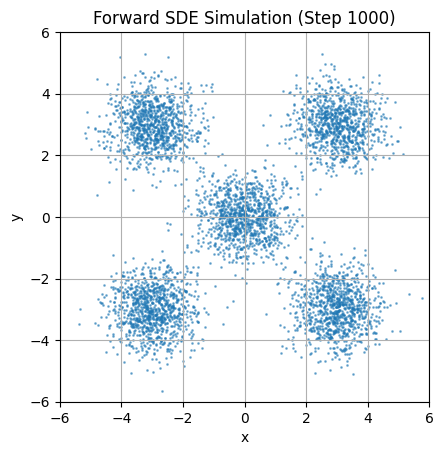

In [17]:
# plot
# traj = simulate_forward_sde(conditional_gmm, bs=bs, n_steps=1000)
# traj = simulate_reverse_sde(torch.randn(bs, 2, device=device), s3_fn, bs=bs, n_steps=1000)

def score_fn(x, t):
    mu_t = alpha_fn(t) * torch.tensor([-3.0, 3.0], device=device).reshape(1,2)  # [B,2]
    var_t = alpha_fn(t)**2 * 0.5**2 + (1.0 - alpha_fn(t)**2)  # [B,1]
    score = -(x - mu_t) / (var_t + 1e-12)  # [B,2]
    return score

x0 = torch.randn(bs, 2, device=device)  # initial samples from N(0,I)
traj = simulate_reverse_sde(x0, s3_fn, bs=bs, n_steps=1000)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
num_snapshots = traj.shape[0]
for i in range(num_snapshots):
    plt.clf()
    plt.scatter(traj[i,:,0], traj[i,:,1], alpha=0.5, s=1)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.title(f"Forward SDE Simulation (Step {i * (1000 // (num_snapshots - 1))})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.gca().set_aspect("equal")
    plt.grid(True)
    plt.pause(0.5)  # Pause to create an animation effect
    from IPython import display
    display.clear_output(wait=True)

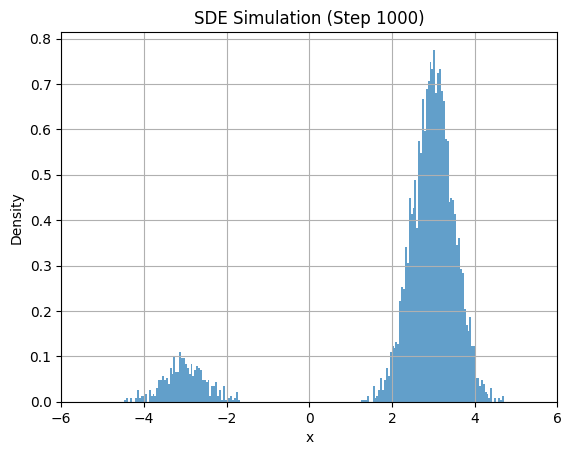

In [15]:
x0 = torch.randn(bs, 1, device=device)  # initial samples from N(0,I)
traj = simulate_reverse_sde(x0, s1_fn, bs=bs, n_steps=1000)

import matplotlib.pyplot as plt

num_snapshots = traj.shape[0]
for i in range(num_snapshots):
    plt.hist(traj[i,:,0], bins=200, density=True, alpha=0.7)
    plt.title(f"SDE Simulation (Step {i * (1000 // (num_snapshots - 1))})")
    plt.xlim(-6, 6)
    plt.grid(True)
    plt.xlabel("x"); plt.ylabel("Density")
    plt.pause(0.5)  # Pause to create an animation effect
    display.clear_output(wait=True)
    from IPython import display

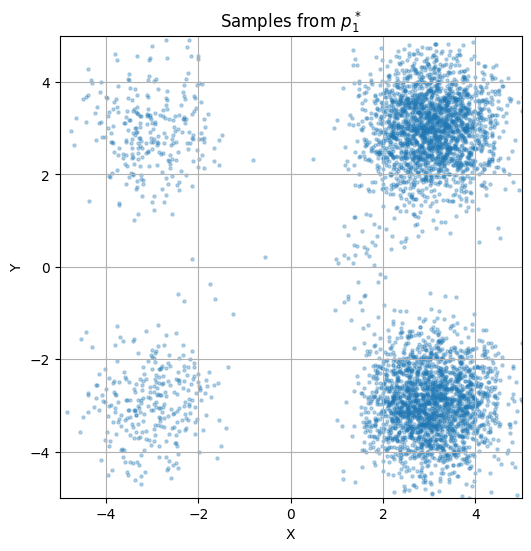

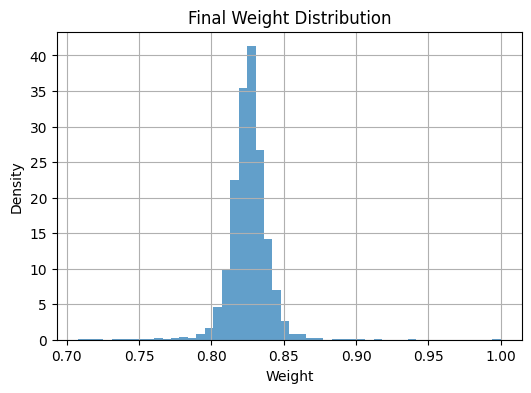

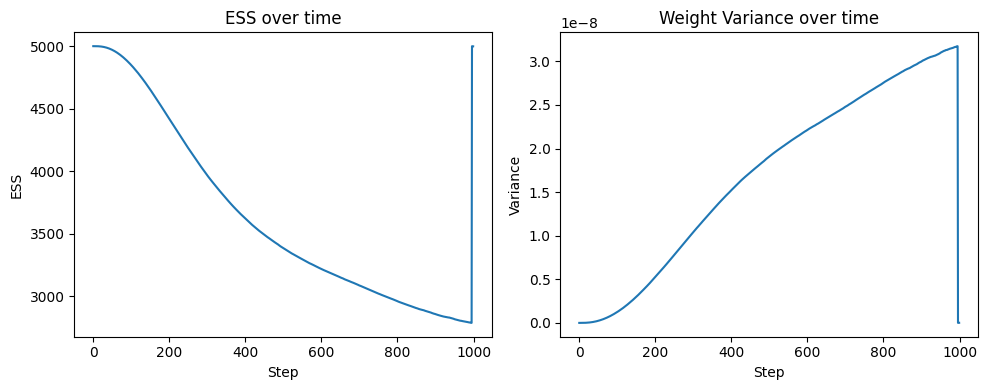

In [ ]:
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t)         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], 1-t), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], 1-t),                                                 # s2(X)
        lambda x, t: s3_fn(x, 1-t)         # s3(Z|B)
    ],
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    #lambda z, t: torch.cat([v1_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

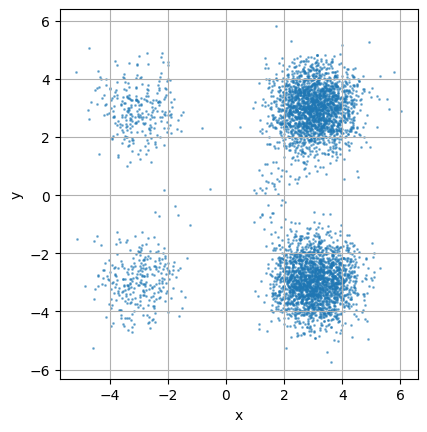

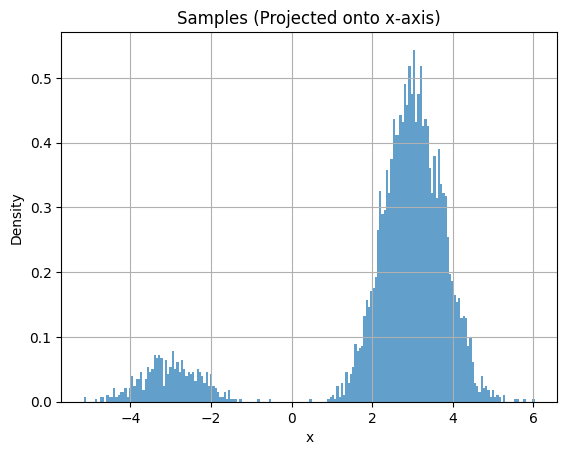

In [12]:
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, s=1)
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect("equal")
plt.grid(True)
plt.show()
plt.clf()

plt.hist(samples[:,0], bins=200, density=True, alpha=0.7)
plt.title("Samples (Projected onto x-axis)")
plt.grid(True)
plt.xlabel("x")#; plt.xlim(-5,5)
plt.ylabel("Density")
plt.show()

In [9]:
results = []
samples_gt = conditional_gmm(bs).numpy()
w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    torch.tensor(samples_gt), torch.tensor(samples)
)
results.append(["HCG[1,-1,1]", w1, w2, mmd_rbf, total_var])
print(results)

[['HCG[1,-1,1]', 0.30251134276946334, 0.6312543950672106, 0.021416306495666504, np.float64(0.6195999999999999)]]


# FKC Baseline - Homogenized Distributions + FKC

### Define homogenized $q^{(1)}$ and $q^{(2)}$.

Extend each 1D density in $X$ to a 2D one by multiplying with a simple factor in $Y$:

$$
q^{(1)}(x,y \mid A) = q^{(1)}(x \mid A) \cdot f(y),
$$

$$
q^{(2)}(x,y) = q^{(2)}(x)\cdot f(y),
$$

where $f(y)$ is a Gaussian $ \mathcal{N}(0,1)$ or uniform on $[-M,M]$.

Then their score functions decompose:

* For $q^{(1)}$:

$$
s^{(1)}(x,y) = \Big(\,\nabla_x \log q^{(1)}(x \mid A), \;\nabla_y \log f(y)\,\Big),
$$

* For $q^{(2)}$:

$$
s^{(2)}(x,y) = \Big(\,\nabla_x \log q^{(2)}(x), \;\nabla_y \log f(y)\,\Big),
$$

* For $q^{(3)}$ (already 2D): $s^{(3)}(x,y)$ as usual.

So you just need to implement `f(y)` and its score.

### Choosing $f(y)$

* If **Gaussian $f(y)\sim\mathcal{N}(0,1)$**: score is just `-y`.
* If **Uniform on \[-M,M]**: score is `0` inside, but undefined at boundary → you’d need to enforce absorbing or reflecting boundaries in simulation. Much easier to stick with Gaussian unless you want hard support constraints.

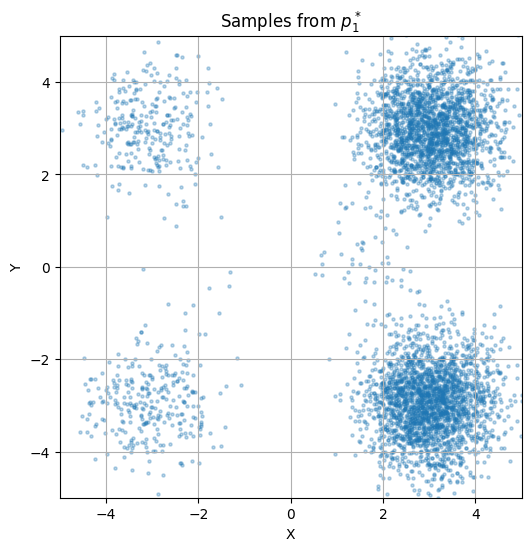

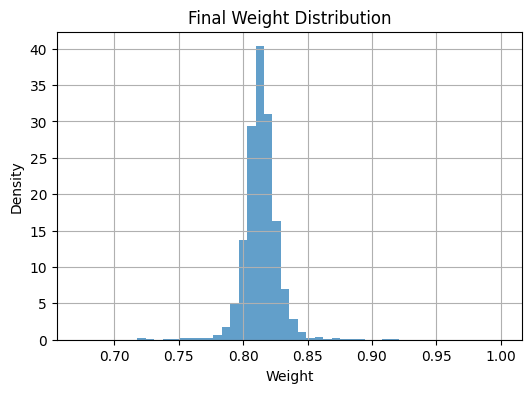

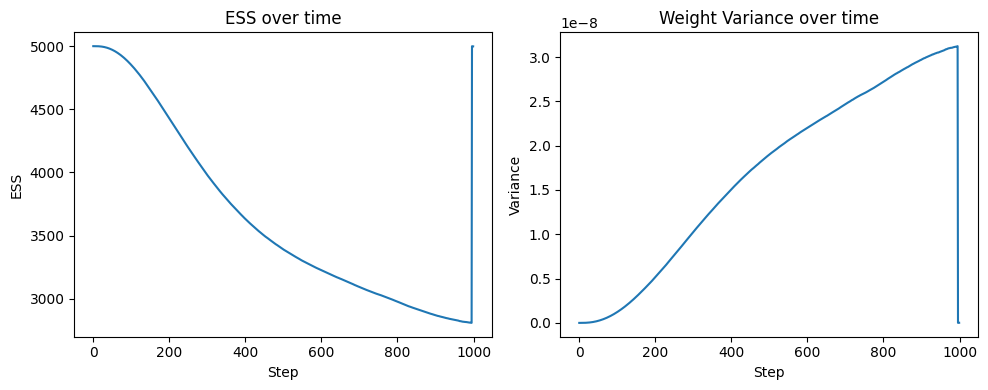

In [ ]:
x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample

# choose f(y) = N(0, 1)  => score s_f(y) = -y
def s_fp(y):           # y has shape (bs,1)
    return -y
def s_fn(y):           # y has shape (bs,1)
    return -y # -0.5*y
def v_fp(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)
def v_fn(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)

# build v_fn_list and s_fn_list that return 2D vectors for (x,y)
v_fn_list = [
    lambda z, t: torch.cat([ v1_fn(z[:, :1], t), v_fp(z[:, 1:2], t) ], dim=1),
    lambda z, t: torch.cat([ v2_fn(z[:, :1], t), v_fn(z[:, 1:2], t) ], dim=1),
    lambda z, t: v3_fn(z, t)   # already 2D
]
s_fn_list = [
    lambda z, t: torch.cat([ s1_fn(z[:, :1], 1-t), s_fp(z[:, 1:2]) ], dim=1),
    lambda z, t: torch.cat([ s2_fn(z[:, :1], 1-t), s_fn(z[:, 1:2]) ], dim=1),
    lambda z, t: s3_fn(z, 1-t)   # already 2D
]
# pass identity projections since all are now 2D
proj_list = [lambda z: z, lambda z: z, lambda z: z]
emb_list = [lambda z: z, lambda z: z, lambda z: z]
# v_star: extend original v1 in x and zero in y
v_star = lambda z, t: v3_fn(z, t)
#lambda z, t: torch.cat([ v1_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device) ], dim=1)


samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[2, 2, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=v_fn_list,
    s_fn_list=s_fn_list,
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=proj_list,
    emb_list=emb_list,
    sigma_fn=sigma_fn,
    v_star=v_star,
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/fkc-1")

In [17]:
results = []
samples_gt = conditional_gmm(bs).numpy()
w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    torch.tensor(samples_gt), torch.tensor(samples)
)
results.append(["FKC[1,-1,1]", w1, w2, mmd_rbf, total_var])
print(results)

[['FKC[1,-1,1]', 0.2932250808457001, 0.5847888883220173, 0.022904694080352783, np.float64(0.6374)]]


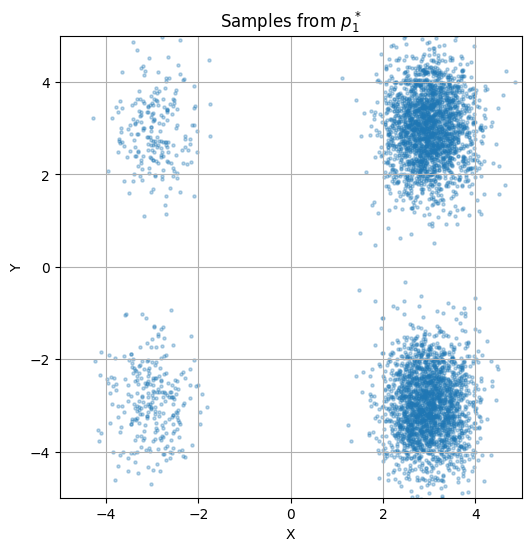

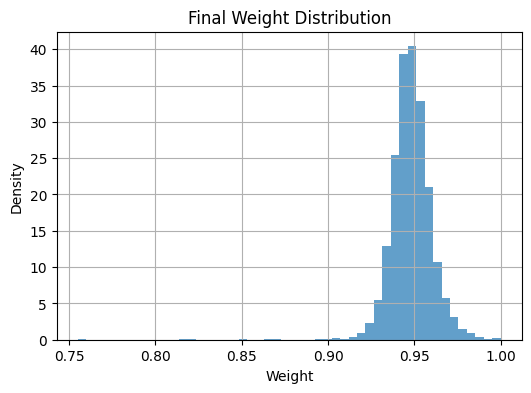

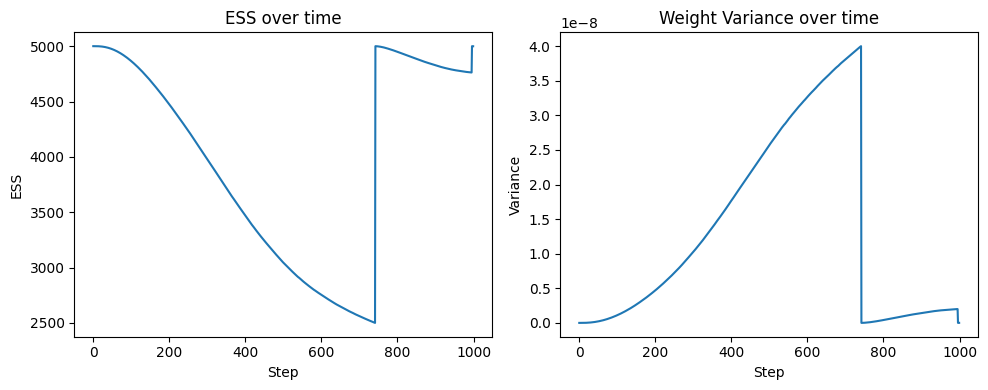

In [ ]:
# Product of Experts

x0 = (1/torch.sqrt(torch.tensor(2))) * torch.randn(bs, 2).to("cuda")  # (X, Y) sample

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t), # v1(X|A)
        lambda x, t: v3_fn(x, t)         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], 1-t), # s1(X|A)
        lambda x, t: s3_fn(x, 1-t)         # s3(Z|B)
    ],
    gamma_list=[1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    #lambda z, t: torch.cat([v1_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

In [19]:
results = []
samples_gt = conditional_gmm_p1p2(bs).numpy()
w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    torch.tensor(samples_gt), torch.tensor(samples)
)
results.append(["HCG[1,1]", w1, w2, mmd_rbf, total_var])
print(results)

[['HCG[1,1]', 0.18747000696811947, 0.5305735042822375, 0.008186757564544678, np.float64(0.5836)]]


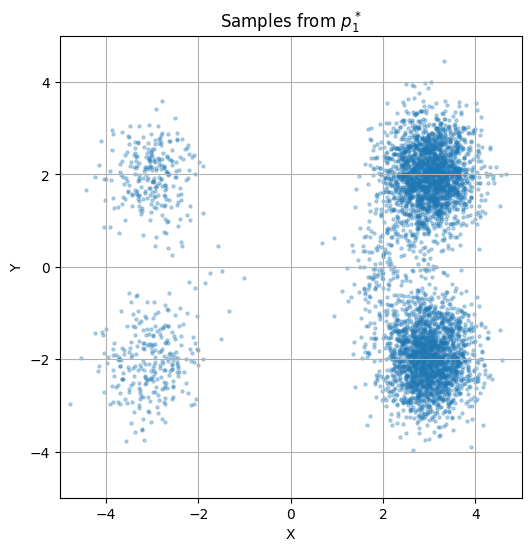

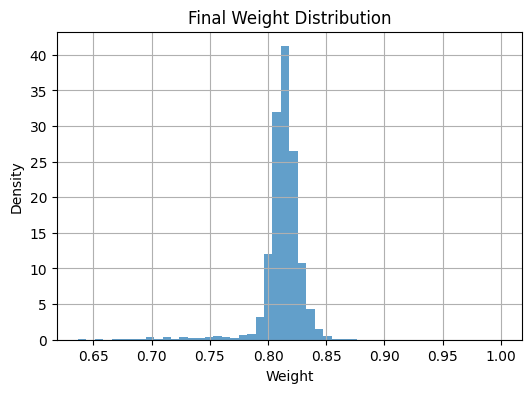

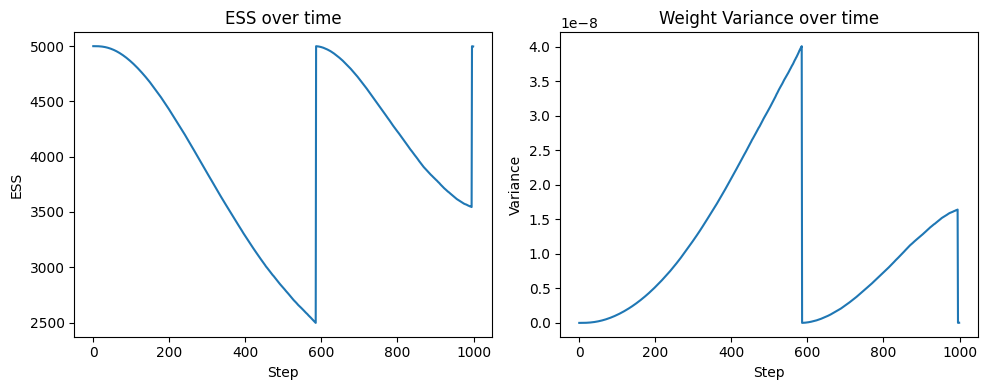

In [ ]:
x0 = (1/torch.sqrt(torch.tensor(2))) * torch.randn(bs, 2).to("cuda")  # (X, Y) sample

# choose f(y) = N(0, 1)  => score s_f(y) = -y
def s_f(y):           # y has shape (bs,1)
    return -y
def v_f(y, t):        # choose zero deterministic drift in y
    return torch.zeros_like(y)

v_fn_list = [
    lambda z, t: torch.cat([ v1_fn(z[:, :1], t), v_f(z[:, 1:2], t) ], dim=1),
    lambda z, t: v3_fn(z, t)   # already 2D
]
s_fn_list = [
    lambda z, t: torch.cat([ s1_fn(z[:, :1], 1-t), s_f(z[:, 1:2]) ], dim=1),
    lambda z, t: s3_fn(z, 1-t)   # already 2D
]
proj_list = [lambda z: z, lambda z: z]
emb_list = [lambda z: z, lambda z: z]
v_star = lambda z, t: v3_fn(z, t)


samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[2, 2],
    v_fn_list=v_fn_list,
    s_fn_list=s_fn_list,
    gamma_list=[1, 1],     # from log-weight increment in simulate_hcg
    proj_list=proj_list,
    emb_list=emb_list,
    sigma_fn=sigma_fn,
    v_star=v_star,
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/fkc-2")

In [21]:
results = []
samples_gt = conditional_gmm_p1p2(bs).numpy()
w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
    torch.tensor(samples_gt), torch.tensor(samples)
)
results.append(["FKC[1,1]", w1, w2, mmd_rbf, total_var])
print(results)

[['FKC[1,1]', 1.0819025206543726, 1.118141558704014, 0.32602596282958984, np.float64(0.7765579080025204)]]


# Evaluation with Metrics

Following the FKC paper, we sample 10k samples with 1000 sampling steps.

# Ratio of Experts $q^1/q^2$

In [ ]:
def sample_data_q1(bs, cond=None, id=0):
    """
    Samples from q^1(x): N(-2, 0.5^2)
    `cond` is a dummy argument for compatibility (e.g., A)
    """
    if id == 0:
        return torch.randn(bs, 1, device=device) + (-2.0), None
    elif id == 1:
        mix = torch.bernoulli(0.9 * torch.ones(bs, 1, device=device))
        left = torch.randn(bs, 1, device=device) + (-2.0)
        right = torch.randn(bs, 1, device=device) + (2.0)
        return mix * right + (1 - mix) * left, None

def sample_data_q2(bs, cond=None, id=0):
    """
    Samples from q^2(x): 50% N(-2, 0.5^2) + 50% N(2, 0.5^2)
    `cond` is a dummy argument for compatibility
    """
    if id == 0:
        mix = torch.bernoulli(0.5 * torch.ones(bs, 1, device=device))
        left = torch.randn(bs, 1, device=device) + (-2.0)
        right = torch.randn(bs, 1, device=device) + (2.0)
        return mix * right + (1 - mix) * left, None

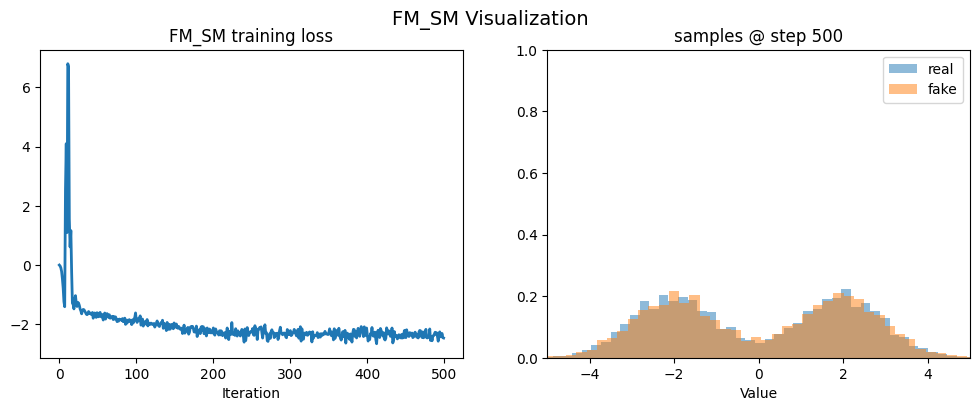

In [ ]:
if True:
    # Training takes ~6s on a single GPU
    u_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    s_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_q1, s_q1, sample_data_q1, plot_cond_val=None, n_iters=500)
    # save the models
    torch.save(u_q1.state_dict(), f"{experiment_id}/ratio_u_q1.pth")
    torch.save(s_q1.state_dict(), f"{experiment_id}/ratio_s_q1.pth")
if True:
    # Training takes ~5s on a single GPU
    u_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    s_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X | A
    run_training_v_s(u_q2, s_q2, sample_data_q2, plot_cond_val=None, n_iters=500)
    # save the models
    torch.save(u_q2.state_dict(), f"{experiment_id}/ratio_u_q2.pth")
    torch.save(s_q2.state_dict(), f"{experiment_id}/ratio_s_q2.pth")

In [ ]:
# q1 / q2 where q1 is a guassian centered at -2 and q2 is a guassian centered at 2 and -2

# Load the saved models
u_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
s_q1 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
u_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
s_q2 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device)
u_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q1.pth"))
s_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_s_q1.pth"))
u_q2.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q2.pth"))
s_q2.load_state_dict(torch.load(f"{experiment_id}/ratio_s_q2.pth"))

# v1: for q^1 (N(-2))
def v1_fn(x, t): return u_q1(x, t)
def s1_fn(x, t): return s_q1(x, t)

# v2: for q^2 (mixture of N(-2), N(+2))
def v2_fn(x, t): return u_q2(x, t)
def s2_fn(x, t): return s_q2(x, t)

# Constant diffusion coefficient
def sigma_fn(t): return torch.ones_like(t)


/tmp/ipykernel_2029843/4289259188.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  u_q1.load_state_dict(torch.load(f"{experiment_id}/ratio_u_q1.pth"))
/tmp/ipykernel_2029

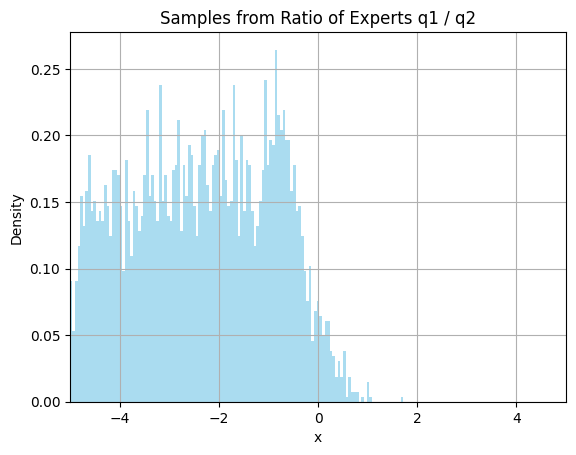

In [ ]:
# Uniform Sample
x0 = torch.rand(bs, 1).to(device) * 10 - 5

samples, logw_final, logw_history, sample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1], 
    v_fn_list=[
        lambda x, t: v1_fn(x, t),                                                 # v1(X)
        lambda x, t: v2_fn(x, t),                                                 # v2(X)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x, t),                                                 # s1(X)
        lambda x, t: s2_fn(x, t),                                                 # s2(X)
    ],
    gamma_list=[1, -1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z, 
        lambda z: z 
    ],
    emb_list=[
        lambda z: z,  # identity
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star= lambda z, t: v2_fn(z, t), 
    t0=0.0, t1=1.0, n_steps=1000,
    device="cuda",
    resample=True,
    ess_threshold=0.5
)
samples = samples.cpu().numpy()
plt.hist(samples, bins=200, density=True, alpha=0.7, color="skyblue")
plt.title("Samples from Ratio of Experts q1 / q2")
plt.grid(True)
plt.xlabel("x"); plt.xlim(-5,5)
plt.ylabel("Density")
plt.show()

In [ ]:
# def ground_truth_gmm_2d(bs):
#     # 2D GMM, p(x, y)
#     n_components = 5
#     weights = np.ones(n_components) / n_components
#     means = np.array([[0, 0], [3, 3], [-3, -3], [3, -3], [-3, 3]])
#     covariances = np.array([[[0.5, 0], [0, 0.5]]] * n_components)
    
#     samples = []
#     while len(samples) < bs:
#         component = np.random.choice(n_components, p=weights)
#         sample = np.random.multivariate_normal(means[component], covariances[component])
#         samples.append(sample)
    
#     return torch.tensor(samples, dtype=torch.float32)

# def ground_truth_gmm_1d(bs):
#     # 1D GMM, p(x | A)
#     n_components = 2
#     weights = np.ones(n_components) / n_components
#     means = np.array([-2, 2])
#     std_devs = np.array([0.5, 0.5])
    
#     samples = []
#     while len(samples) < bs:
#         component = np.random.choice(n_components, p=weights)
#         sample = np.random.normal(means[component], std_devs[component])
#         samples.append(sample)
    
#     return torch.tensor(samples, dtype=torch.float32).unsqueeze(1)

# def conditional_gmm(bs):
#     # 2D GMM conditioned on 1D variable A
#     # Samples from p(x, y | A) = p(x,y) p(x | A) / p(x)

# def ground_truth_gmm_1d(bs):
#     n_components = 2
#     weights = np.ones(n_components) / n_components
#     means = np.array([-2, 2])
#     std_devs = np.array([0.5, 0.5])
    
#     samples = []
#     while len(samples) < bs:
#         component = np.random.choice(n_components, p=weights)
#         sample = np.random.normal(means[component], std_devs[component])
#         samples.append(sample)
    
#     return torch.tensor(samples, dtype=torch.float32).unsqueeze(1)


In [ ]:
# _TWOPI = 2.0 * math.pi

# # -------------------------
# # Time schedules (batch-aware)
# # -------------------------
# def alpha_fn(t):
#     # t: [B,1]
#     return 1.0 - t          # [B,1]

# def beta_fn(t):
#     # t: [B,1]
#     return 2.0 / (1.0 - t + 1e-12)  # [B,1]

# def sigma_fn(t):
#     return torch.sqrt(beta_fn(t))    # [B,1]

# # -------------------------
# # Stable 1D log-normal
# # -------------------------
# def _log_normal_(x, mu, var, dim=1):
#     if dim == 1:
#         # x: [B,1], mu: [B,K], var: [B,K]
#         log_pref = -0.5 * torch.log(_TWOPI * var)    # [B,K]
#         exp_term = -0.5 * ((x - mu)**2) / var        # [B,K]
#         return log_pref + exp_term                    # [B,K]
#     else:
#         # x: [B,D], mu: [B,K,D], var: [B,K]
#         diff2 = ((x.unsqueeze(1) - mu)**2).sum(-1)   # [B,K]
#         D = x.shape[1]
#         log_pref = -0.5 * D * torch.log(_TWOPI * var)   # [B,K]
#         exp_term = -0.5 * diff2 / var                    # [B,K]
#         return log_pref + exp_term                        # [B,K]

# def s1_fn(x, t):
#     """
#     x: [B,1], t: [B,1]
#     returns: score of same shape as x
#     """
#     device = x.device
#     dtype = x.dtype
#     B = x.shape[0]

#     # GMM parameters for p(x|A)
#     pis = torch.tensor([0.1, 0.9], device=device, dtype=dtype)    # [K]
#     mus0 = torch.tensor([-3.0, 3.0], device=device, dtype=dtype) # [K]
#     sig2_0 = torch.tensor([0.5**2, 0.5**2], device=device, dtype=dtype) # [K]

#     K = pis.shape[0]

#     # schedule
#     alpha = alpha_fn(t)                  # [B,1]
#     s2 = 1.0 - alpha**2                  # [B,1]

#     # batch-aware component params: mu_t [B,K], tau2 [B,K]
#     mu_t = alpha * mus0.reshape(1,K)     # [B,K]
#     tau2 = alpha**2 * sig2_0.reshape(1,K) + s2  # [B,K]

#     # log components [B,K]
#     x_in = x.reshape(B,1)                # [B,1]
#     log_comp = torch.log(pis.reshape(1,K)) + _log_normal_1d(x_in, mu_t, tau2)  # [B,K]

#     # responsibilities
#     logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
#     r = torch.exp(log_comp - logp)                           # [B,K]

#     # component scores
#     comp_scores = (mu_t - x_in) / (tau2 + _eps)  # [B,K]
#     score = (r * comp_scores).sum(dim=1, keepdim=True)  # [B,1]

#     if x.ndim == 2 and x.shape[1] == 1:
#         return score
#     else:
#         return score.reshape(-1)  # [B]
    
# print(s1_fn(torch.tensor([[3.0],[0.0],[-3.0]]), torch.tensor([[0.0],[0.5],[1.0]])))  # expect ~ [0, -0.8, 0]

In [ ]:
import torch
import math

_eps = 1e-12
_TWOPI = 2.0 * math.pi

def alpha_fn(t):
    # t: scalar or tensor; return scalar/tensor same device/dtype as t
    if not torch.is_tensor(t):
        t = torch.tensor(t)
    return (1.0 - t)

def beta_fn(t):
    # For alpha(t) = 1-t, beta(t) = - d/dt log(alpha^2) = 2/(1-t)
    if not torch.is_tensor(t):
        t = torch.tensor(t)
    return 2.0 / (1.0 - t + 1e-12)

def sigma_fn(t): 
    return torch.sqrt(beta_fn(t))

# -------------------------
# Helper: stable log-normal (1D)
# -------------------------
def _log_normal_1d(x, mu, var):
    # x: [B,1] or [B], mu: [K] or scalar, var: [K] or scalar
    # returns log_prob [B,K]
    x = x.reshape(-1, 1)  # [B,1]
    mu = torch.as_tensor(mu, device=x.device, dtype=x.dtype).reshape(1, -1)  # [1,K]
    var = torch.as_tensor(var, device=x.device, dtype=x.dtype).reshape(1, -1)  # [1,K]
    log_pref = -0.5 * torch.log(_TWOPI * var)    # [1,K]
    exp_term = -0.5 * ((x - mu) ** 2) / var      # [B,K]
    return log_pref + exp_term                   # [B,K]

# -------------------------
# 1D time-dependent score for p(x|A)
# -------------------------
def s1_fn(x, t):
    """
    x: tensor shape [B,1]
    t: tensor shape [B,1] in [0,1]
    returns: score tensor shape [B,1]
    """
    device = x.device
    dtype = x.dtype

    # GMM parameters for p(x|A)
    pis = torch.tensor([0.1, 0.9], device=device, dtype=dtype)   # K=2
    mus0 = torch.tensor([-3.0, 3.0], device=device, dtype=dtype)
    sig2_0 = torch.tensor([0.5**2, 0.5**2], device=device, dtype=dtype)  # variances

    # schedule
    alpha = alpha_fn(t).to(device=device, dtype=dtype)   # scalar
    s2 = 1.0 - alpha**2                                  # added variance
    # component time params
    mu_t = alpha * mus0.reshape(1, -1)                   # [B,K]
    tau2 = alpha**2 * sig2_0.reshape(1, -1) + s2         # [B,K]

    # prepare x
    x_in = x.reshape(-1)                 # [B]
    B = x_in.shape[0]

    # log components (B, K)
    log_comp = torch.log(pis.to(device=device, dtype=dtype)).reshape(1, -1) + _log_normal_1d(x_in, mu_t, tau2)

    # log p_t(x) and responsibilities
    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    log_r = log_comp - logp                                 # [B,K]
    r = torch.exp(log_r)                                    # [B,K], sums to 1

    # component scores: (mu_t - x) / tau2  -> shape [B,K]
    comp_scores = (mu_t - x_in.reshape(-1,1)) / (tau2 + _eps)  # [B,K]

    score = (r * comp_scores).sum(dim=1)   # [B]
    # return in same shape as input x
    if x.ndim == 2 and x.shape[1] == 1:
        return score.reshape(-1,1)
    else:
        return score

# -------------------------
# Helper: stable log-normal (multivariate isotropic)
# -------------------------
def _log_normal_isotropic(x, mus, tau2):
    # x: [B,D], mus: [B,K,D], tau2: [B,K] (variance scalar per component)
    # returns log_prob [B,K]
    # B, D = x.shape
    # K = mus.shape[0]
    # x -> [B,1,D], mus -> [1,K,D]
    # x_exp = x.unsqueeze(1)        # [B,1,D]
    # mus_exp = mus.unsqueeze(0)    # [1,K,D]
    # diff2 = ((x_exp - mus_exp) ** 2).sum(dim=-1)  # [B,K] squared Mahalanobis (isotropic)
    # tau2 = tau2.reshape(1, -1)    # [1,K]
    diff2 = ((x.unsqueeze(1) - mus)**2).sum(-1)  # [B,K]
    log_pref = -0.5 * (x.shape[1] * torch.log(_TWOPI * tau2))  # [B,K]
    exp_term = -0.5 * diff2 / tau2                       # [B,K]
    return log_pref + exp_term                           # [B,K]

# -------------------------
# 2D time-dependent score for p_X (2D GMM)
# -------------------------
def s2_fn(x, t):
    """
    x: tensor shape [B,2]
    t: scalar (float or 0-dim tensor) in [0,1]
    returns: score tensor shape [B,2]
    """
    device = x.device
    dtype = x.dtype

    # Parameters for 2D GMM (K=5)
    K = 5
    pis = torch.ones(K, device=device, dtype=dtype) / K
    mus0 = torch.tensor([[0.,0.],[3.,3.],[-3.,-3.],[3.,-3.],[-3.,3.]], device=device, dtype=dtype)  # [K,2]
    # initial isotropic variances (sigma^2) per component (here 0.5)
    sig2_0 = torch.tensor([0.5, 0.5, 0.5, 0.5, 0.5], device=device, dtype=dtype)   # [K] variances

    # schedule
    alpha = alpha_fn(t).to(device=device, dtype=dtype)   # scalar
    s2 = 1.0 - alpha**2                                  # added variance

    # time-evolved component params
    print(alpha.shape, mus0.shape, sig2_0.shape, s2.shape)
    mu_t = alpha.unsqueeze(-1) * mus0.unsqueeze(0)            # [B,K,2]
    tau2 = alpha**2 * sig2_0.reshape(1,K) + s2  # [B,K]

    # prepare x
    x_in = x.reshape(-1, 2)        # [B,2]
    B = x_in.shape[0]

    # log component densities: [B,K]
    log_comp = torch.log(pis.to(device=device, dtype=dtype)).reshape(1,-1) + _log_normal_isotropic(x_in, mu_t, tau2)

    # log p_t(x) and responsibilities
    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    log_r = log_comp - logp                                 # [B,K]
    r = torch.exp(log_r)                                    # [B,K]

    # component score vectors: (mu_t - x) / tau2  -> shape [B,K,2]
    # mu_t: [K,2] -> [1,K,2], x_in: [B,2] -> [B,1,2]
    mu_t_exp = mu_t.unsqueeze(0)            # [1,K,2]
    x_exp = x_in.unsqueeze(1)               # [B,1,2]
    tau2_exp = tau2.reshape(B, K, 1)        # [B,K,1]
    comp_scores = (mu_t_exp - x_exp) / (tau2_exp + _eps)   # [B,K,2]

    # weight by responsibilities and sum over K
    r_exp = r.unsqueeze(-1)                 # [B,K,1]
    score = (r_exp * comp_scores).sum(dim=1) # [B,2]
    print("s2_fn: ",score.shape, x.shape, r_exp.shape, comp_scores.shape)
    return score

# -------------------------
# 1D time-dependent score for p(x)
# -------------------------
def s3_fn(x, t):
    """
    x: tensor shape [B] or [B,1]
    t: scalar (float or 0-dim tensor) in [0,1]
    returns: score tensor shape same as x (i.e., [B] or [B,1])
    """
    device = x.device
    dtype = x.dtype

    # GMM parameters for p(x|A)
    pis = torch.tensor([0.4, 0.2, 0.4], device=device, dtype=dtype)   # K=2
    mus0 = torch.tensor([-3.0, 0.0, 3.0], device=device, dtype=dtype)
    sig2_0 = torch.tensor([0.5**2, 0.5**2, 0.5**2], device=device, dtype=dtype)  # variances

    # schedule
    alpha = alpha_fn(t).to(device=device, dtype=dtype)   # scalar
    s2 = 1.0 - alpha**2                                  # added variance
    # component time params
    mu_t = alpha * mus0.reshape(1,-1)                    # [B,K]
    tau2 = alpha**2 * sig2_0.reshape(1,-1) + s2          # [B,K]

    # prepare x
    x_in = x.reshape(-1)                 # [B]
    B = x_in.shape[0]

    # log components (B, K)
    log_comp = torch.log(pis.to(device=device, dtype=dtype)).reshape(1, -1) + _log_normal_1d(x_in, mu_t, tau2)

    # log p_t(x) and responsibilities
    logp = torch.logsumexp(log_comp, dim=1, keepdim=True)   # [B,1]
    log_r = log_comp - logp                                 # [B,K]
    r = torch.exp(log_r)                                    # [B,K], sums to 1

    # component scores: (mu_t - x) / tau2  -> shape [B,K]
    mu_t_ = mu_t.reshape(1, -1)   # [1,K]
    tau2_ = tau2.reshape(1, -1)   # [1,K]
    comp_scores = (mu_t_ - x_in.reshape(-1,1)) / (tau2_ + _eps)  # [B,K]

    score = (r * comp_scores).sum(dim=1)   # [B]
    # return in same shape as input x
    if x.ndim == 2 and x.shape[1] == 1:
        return score.reshape(-1,1)
    else:
        return score

# --- define the drifts ---
def v1_fn(x, t):
    # x: [B,1], t: [B,1]
    beta_one_minus_t = beta_fn(1-t).to(device=x.device, dtype=x.dtype)
    drift = 0.5 * beta_one_minus_t * x + 0.5 * beta_one_minus_t * s1_fn(x, 1-t)
    return drift
def v2_fn(x, t):
    # x: [B,2], t: [B,1]
    beta_one_minus_t = beta_fn(1-t).to(device=x.device, dtype=x.dtype)
    print(beta_one_minus_t.shape, x.shape, s2_fn(x, 1-t).shape)
    drift = 0.5 * beta_one_minus_t * x + 0.5 * beta_one_minus_t * s2_fn(x, 1-t)
    return drift
def v3_fn(x, t):
    # x: [B,1], t: [B,1]
    beta_one_minus_t = beta_fn(1-t).to(device=x.device, dtype=x.dtype)
    drift = 0.5 * beta_one_minus_t * x + 0.5 * beta_one_minus_t * s3_fn(x, 1-t)
    return drift